# Importing Libraries

In [5]:
import pandas as pd
import numpy as np

import geopandas as gpd
import folium
from folium.plugins import HeatMap
import pydeck as pdk
import hashlib



import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import make_blobs

from shapely import wkt

# Loading DF

In [ ]:
pre_norm_df_final = pd.read_csv('..\Data\\display_rdy_data_4.csv', low_memory=False)
norm_df = pd.read_csv('..\Data\\norm_data_5.csv', low_memory=False)


# PCA

In [ ]:
# # Run PCA and automatically find the optimal components
# # We initially set the n_components to 85% in order to keep 85% of the original information and lose only 15%
# pca_optimal = PCA(n_components=0.85, random_state=42)
# X_pca = pca_optimal.fit_transform(X_scaled)

# # Extract number of needed components
# best_n = pca_optimal.n_components_
# print(f"To retain 85% of the data's variance, PCA selected {best_n} components.")

# # Generate PCA columns
# pca_columns = [f"PCA_{i}" for i in range(1, best_n + 1)]

# Clustering Hierarchical

In [13]:
# Print clustering output
def output(labels):
    labels = pd.Series(labels)
    print("The labels:\n", labels)
    print("===================")
    print("Cluster Counts:\n", labels.value_counts())


In [8]:
# Drop incident zip column
Features = norm_df.drop("Incident_Zip", axis=1)

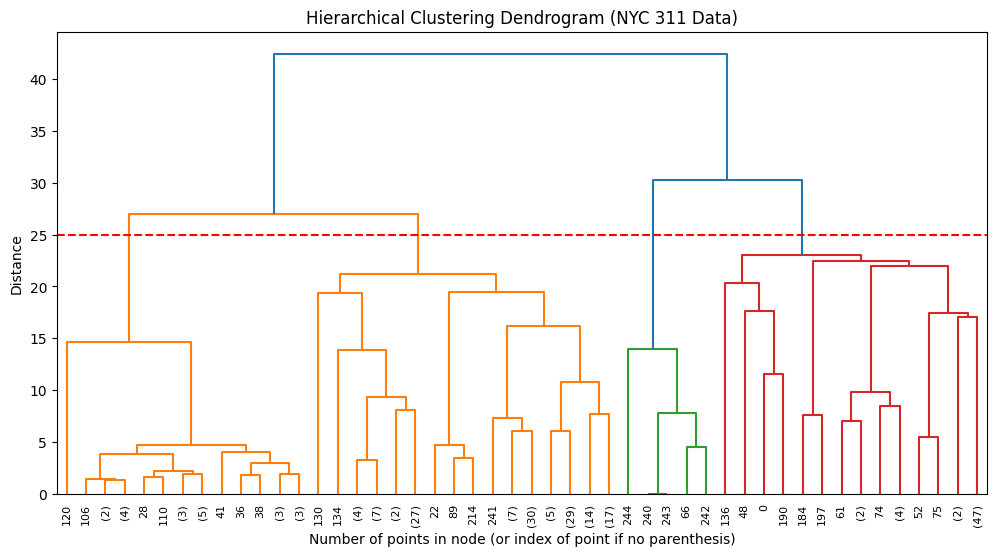

In [ ]:
# Fitting the model 
agg = AgglomerativeClustering(
    distance_threshold=0,
    n_clusters=None,
    compute_distances=True
)
agg.fit(Features)

# Dendrogram plot func
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


# Plot the Dendrogram
plt.figure(figsize=(12, 6))
plot_dendrogram(agg, truncate_mode='level', p=6) # p is rendreing limit
plt.title("Hierarchical Clustering Dendrogram (NYC 311 Data)")
plt.xlabel("Number of points in node (or index of point if no parenthesis)")
plt.ylabel("Distance")
plt.axhline(y=25, color='r', linestyle='--') 
plt.show()


In [22]:
# Get labels
final_clustering = AgglomerativeClustering(n_clusters=4)
labels = final_clustering.fit_predict(Features)
pre_norm_df_final['Cluster'] = labels
output(labels)

The labels:
 0      0
1      0
2      1
3      1
4      1
      ..
240    2
241    1
242    2
243    2
244    2
Length: 245, dtype: int64
Cluster Counts:
 1    148
0     65
3     27
2      5
Name: count, dtype: int64


# Draw the results on a map

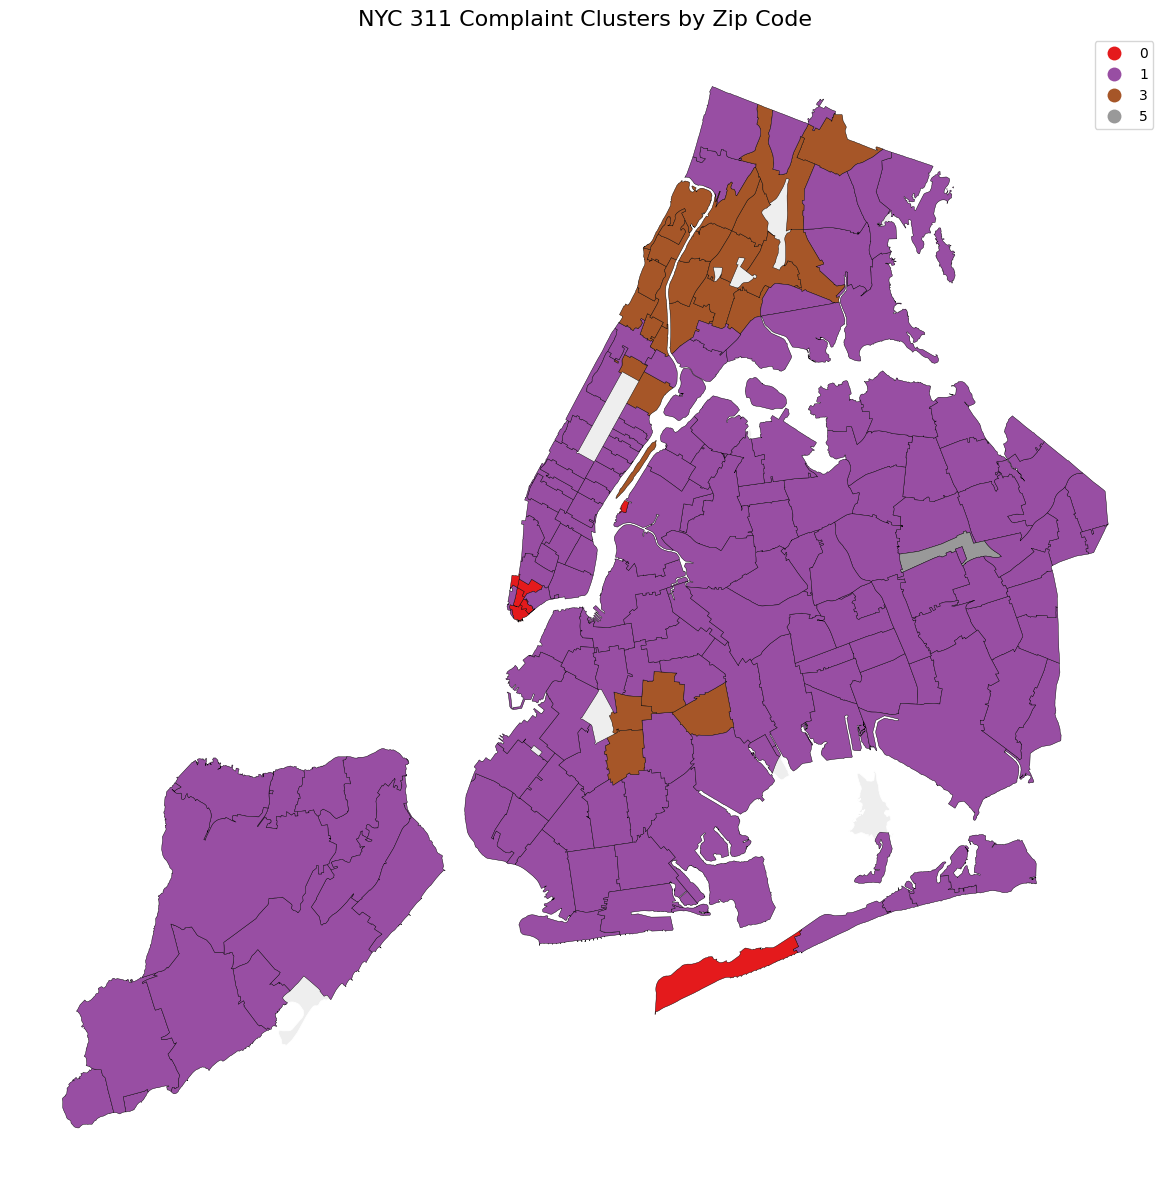

In [ ]:
# 1. Fetch the official NYC Zip Code GeoJSON directly from NYC Open Data
nyc_map = gpd.read_file("Data\Modified Zip Code Tabulation Areas (MODZCTA).geojson")

# 2. Prepare your dataframe for the merge
# Assuming 'Incident_Zip' is currently the index from the previous steps
pree_norm_df_final = pre_norm_df_final.reset_index()

# Both columns must be strings to merge properly
pree_norm_df_final['Incident_Zip'] = pree_norm_df_final['Incident_Zip'].astype(str)
nyc_map['modzcta'] = nyc_map['modzcta'].astype(str)

# 3. Merge the geographic polygons with your clustering labels
# We use an 'inner' merge so we only map the zip codes that exist in your 245-row dataset
mapped_clusters = nyc_map.merge(pree_norm_df_final, left_on='modzcta', right_on='Incident_Zip', how='inner')

# 4. Plot the Choropleth Map
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Optional: Plot a light grey base map of ALL NYC zip codes behind your data
# This provides visual context for any zip codes missing from your dataset
nyc_map.plot(ax=ax, color='#eeeeee', edgecolor='white', linewidth=0.5)

# Plot your specific clusters
mapped_clusters.plot(
    column='Cluster', 
    ax=ax, 
    categorical=True, 
    legend=True,
    cmap='Set1', # A sharp colormap for distinct categories
    edgecolor='black',
    linewidth=0.3
)

plt.title('NYC 311 Complaint Clusters by Zip Code', fontsize=16)
plt.axis('off') # Hides the latitude/longitude axes for a cleaner map
plt.tight_layout()
plt.show()